# 3.0 PCA-plots

In [1]:
pip install numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, normalize
import sklearn.decomposition
import matplotlib.pyplot as plt
import numpy as np
import mpl_axes_aligner

Loading data:

In [2]:
corpus_df = pd.read_pickle('data\dataframe_corpus_expanded.pkl.gz', compression='gzip')
corpus_df

,author,title,lines,lines_lemmatized,lines_pos,lines_lemma_and_pos
0,Heelu,rijmkroniek van woeringen,"[Vrouwe Margriete van Inghelant, Die seker hev...","[vrouwe NOU-P van NOU-P, die zeker hebben van ...","[NOU-C(number=sg) NOU-P ADP(type=pre) NOU-P, P...","[[(vrouwe, NOU-C(number=sg)), (NOU-P, NOU-P), ..."
1,Velthem,vijfde partie,[Vanden lantgrave van Doringen hoene die paus ...,[van de landgraaf van NOU-P hoen die paus ten ...,"[ADP(type=pre) PD(type=d-p,subtype=art,positio...","[[(van, ADP(type=pre)), (de, PD(type=d-p,subty..."
2,Velthem,woeringen-adaptatie,"[Coene hovesch milde ende weert, In allen land...","[koen hoofs mild en waard, in al land zeer ver...","[AA(degree=pos,position=free) AA(degree=pos,po...","[[(koen, AA(degree=pos,position=free)), (hoofs..."
3,Velthem,vijfde partie (zonder woeringen-adaptatie),[Vanden lantgrave van Doringen hoene die paus ...,[van de landgraaf van NOU-P hoen die paus ten ...,"[ADP(type=pre) PD(type=d-p,subtype=art,positio...","[[(van, ADP(type=pre)), (de, PD(type=d-p,subty..."


## 3.1 PCA-plot based on rhyme pairs

### *Slag bij Woeringen* (Heelu) vs. *Woeringen*-adaptatie (Velthem) vs. Vijfde Partie zonder *Woeringen*-adaptatie (Velthem)

In [3]:
# extract all rhyme words for each text and divide them into segments of equal length
def segment(work_df, rhyme_only=True, incl_lemma=True, incl_pos=False, segment_length = 2000, min_length=1364):        
    if not (incl_pos or incl_lemma):
        raise ValueError('incl_lemma OR incl_pos must be set to True')

    segments = []

    for _, row in tqdm(list(work_df.iterrows())):
        if rhyme_only:
            #"if verse" was added to skip empty verse lines (lacuna). In the parse_xml function empty lists [] were yielded
            #so that verse counts remained accurate
            text = [verse[-1] for verse in row['lines_lemma_and_pos'] if verse]
        else:
            text = [item for sublist in row['lines_lemma_and_pos'] for item in sublist]
        
        if incl_lemma and incl_pos:
            text = ['@'.join(p) for p in text]
        elif incl_lemma:
            text = [p[0] for p in text]
        else:
            text = [p[1] for p in text]

        meta = [row['title'], row['author']]
        
        if segment_length:
            if len(text) < segment_length:
                continue
            si, ei, idx = 0, segment_length, 1
            while ei < len(text):
                segments.append(meta + [idx, text[si:ei]])
                idx += 1
                si += segment_length
                ei += segment_length
        else:
            if len(text) >= min_length:
                segments.append(meta + [0, text])

    return pd.DataFrame(segments, columns=['title', 'author', 'segment-idx', 'All_rhyme_words'])
#Rhyme only! for rows with idx 0 (Slag bij Woeringen) and idx 2 (woeringen adaptation)
segment_df = segment(corpus_df.iloc[[0,2, 3]], rhyme_only=True, incl_pos=False, segment_length=1412) #segment_length has been changed to 1412 so the entirety of the Woeringen adaptation will be utilised (only the last line was not included)
segment_df.head(10)

100%|██████████| 3/3 [00:00<00:00, 148.17it/s]


,title,author,segment-idx,All_rhyme_words
0,rijmkroniek van woeringen,Heelu,1,"[NOU-P, NOU-P, NOU-P, kunnen, gift, gedicht, m..."
1,rijmkroniek van woeringen,Heelu,2,"[worden, uitvaart, oog, geloven, dat, stad, ar..."
2,rijmkroniek van woeringen,Heelu,3,"[zullen, houden, hand, NOU-P, hulp, NOU-P, daa..."
3,rijmkroniek van woeringen,Heelu,4,"[vergeten, vaten, ontginnen, ontrinnen, versli..."
4,rijmkroniek van woeringen,Heelu,5,"[oosterling, ding, everzwijn, zijn, zwaard, on..."
5,rijmkroniek van woeringen,Heelu,6,"[gerijzen, taal, NOU-P, NOU-P, hand, geweer, h..."
6,woeringen-adaptatie,Velthem,1,"[waard, vermaard, tornooispel, veel, begeven, ..."
7,woeringen-adaptatie,Velthem,2,"[beliggen, lijden, rijden, duren, avonturen, l..."
8,vijfde partie (zonder woeringen-adaptatie),Velthem,1,"[j, doen, groot, innocent, consent, NOU-P, bed..."
9,vijfde partie (zonder woeringen-adaptatie),Velthem,2,"[bloed, goed, maat, caritaat, minnen, gewinnen..."


In [4]:
segment_df.tail(10)

,title,author,segment-idx,All_rhyme_words
15,vijfde partie (zonder woeringen-adaptatie),Velthem,8,"[ding, wel, taal, naan, doen, ziel, nedervalle..."
16,vijfde partie (zonder woeringen-adaptatie),Velthem,9,"[in, begin, zien, dag, dat, zien, staan, wonde..."
17,vijfde partie (zonder woeringen-adaptatie),Velthem,10,"[trier, dragen, slaan, zitten, eten, brouwen, ..."
18,vijfde partie (zonder woeringen-adaptatie),Velthem,11,"[daar, overwaar, tijgen, vermogen, zullen, wil..."
19,vijfde partie (zonder woeringen-adaptatie),Velthem,12,"[ras, harnas, doen, stede, daad, kwaad, voort,..."
20,vijfde partie (zonder woeringen-adaptatie),Velthem,13,"[verstaan, latrane, plegen, ontwegen, deze, wi..."
21,vijfde partie (zonder woeringen-adaptatie),Velthem,14,"[zijn, dat, stad, stonde, kond, lieden, geschi..."
22,vijfde partie (zonder woeringen-adaptatie),Velthem,15,"[tijd, zijde, pont, staan, pond, kerstavond, g..."
23,vijfde partie (zonder woeringen-adaptatie),Velthem,16,"[geduren, macht, kracht, komen, gomen, jegen, ..."
24,vijfde partie (zonder woeringen-adaptatie),Velthem,17,"[gerechtigheid, nijdigheid, onder, wonder, kwa..."


In [5]:
#Inspect segments
segment_df.iloc[17]['All_rhyme_words'][-10:]

['voorttijgen',
 'vermogen',
 'vaart',
 'geschard',
 'vernemen',
 'komen',
 'lachen',
 'slag',
 'omtrent',
 'NOU-P']

In [6]:
def bigrams(text):
    for i in range(len(text)-1):
        if 'NOU-P' not in text[i:i+2]:
            yield '-'.join((sorted(text[i:i+2])))

# vectorizing
params = {'use_idf': True,
          'max_features': 1000, #(the maximun is 3623 for this corpus with min_df=2)
          'analyzer': bigrams,
          'min_df': 2}

vectorizer = TfidfVectorizer(**params)
BOW = vectorizer.fit_transform(segment_df['All_rhyme_words']).toarray()
BOW = StandardScaler().fit_transform(BOW)

In [7]:
#Visualisation of the BOW as a dataframe
BOW_df = pd.DataFrame(BOW, columns = vectorizer.get_feature_names_out())

print(len(BOW)) #there are 25 segments
print(len(BOW) == len(segment_df)) #sanity check
#BOW_df.head()
print(len(BOW_df))
BOW_df.head()

25
True
25


,Brabantsoen-koen,aan-dan,aan-man,aan-mede,aan-verstaan,aanzien-verstaan,aard-waart,aarde-zwaard,achten-brengen,achter-lachter,...,worden-worden,worden-zwaard,wraken-zaak,zaan-zijn,zaan-zullen,zagen-zijn,zeer-zijn,zeggen-zijn,zijde-zijn,zijn-zijn
0,1.339766,-0.674568,-0.69107,-0.397085,-0.329795,-0.431479,-0.339241,-0.429586,-0.411299,0.789641,...,3.918315,-0.277879,-0.283274,-0.471767,-0.497073,1.766627,-0.557644,-0.497921,-0.491187,-0.947111
1,-0.414048,-0.674568,-0.69107,-0.397085,-0.329795,-0.431479,-0.339241,-0.429586,-0.411299,-0.578337,...,-0.347561,4.378858,-0.283274,-0.471767,-0.497073,-0.346026,1.629952,-0.497921,-0.491187,-0.947111
2,-0.414048,-0.674568,-0.69107,-0.397085,-0.329795,-0.431479,-0.339241,-0.429586,1.546682,-0.578337,...,-0.347561,-0.277879,-0.283274,-0.471767,-0.497073,-0.346026,-0.557644,-0.497921,-0.491187,-0.947111
3,1.437520,-0.674568,-0.69107,-0.397085,-0.329795,-0.431479,4.098373,-0.429586,-0.411299,-0.578337,...,-0.347561,-0.277879,-0.283274,-0.471767,-0.497073,1.884382,-0.557644,-0.497921,-0.491187,-0.947111
4,3.078597,-0.674568,-0.69107,-0.397085,-0.329795,-0.431479,1.753446,1.936940,3.575253,-0.578337,...,-0.347561,2.012365,-0.283274,-0.471767,-0.497073,-0.346026,-0.557644,2.161295,1.827124,-0.947111


In [8]:
labels = []
for entry, nr in zip(segment_df['title'], segment_df['segment-idx']):
    if entry == "rijmkroniek van woeringen":
        labels.append(f"Heelu_{nr}")
    elif entry == "woeringen-adaptatie":
        labels.append(f"Velthem (Wo)_{nr}")
    elif entry == "vijfde partie (zonder woeringen-adaptatie)":
        labels.append(f"Velthem (excl. Wo)_{nr}")
labels

['Heelu_1',
 'Heelu_2',
 'Heelu_3',
 'Heelu_4',
 'Heelu_5',
 'Heelu_6',
 'Velthem (Wo)_1',
 'Velthem (Wo)_2',
 'Velthem (excl. Wo)_1',
 'Velthem (excl. Wo)_2',
 'Velthem (excl. Wo)_3',
 'Velthem (excl. Wo)_4',
 'Velthem (excl. Wo)_5',
 'Velthem (excl. Wo)_6',
 'Velthem (excl. Wo)_7',
 'Velthem (excl. Wo)_8',
 'Velthem (excl. Wo)_9',
 'Velthem (excl. Wo)_10',
 'Velthem (excl. Wo)_11',
 'Velthem (excl. Wo)_12',
 'Velthem (excl. Wo)_13',
 'Velthem (excl. Wo)_14',
 'Velthem (excl. Wo)_15',
 'Velthem (excl. Wo)_16',
 'Velthem (excl. Wo)_17']

The code in the cell below is originally from the notebooks for *The One and Only? Authorship Verification on Jan van
Boendale and the Middle Dutch Antwerp School* by Caroline Vandyck (2025):

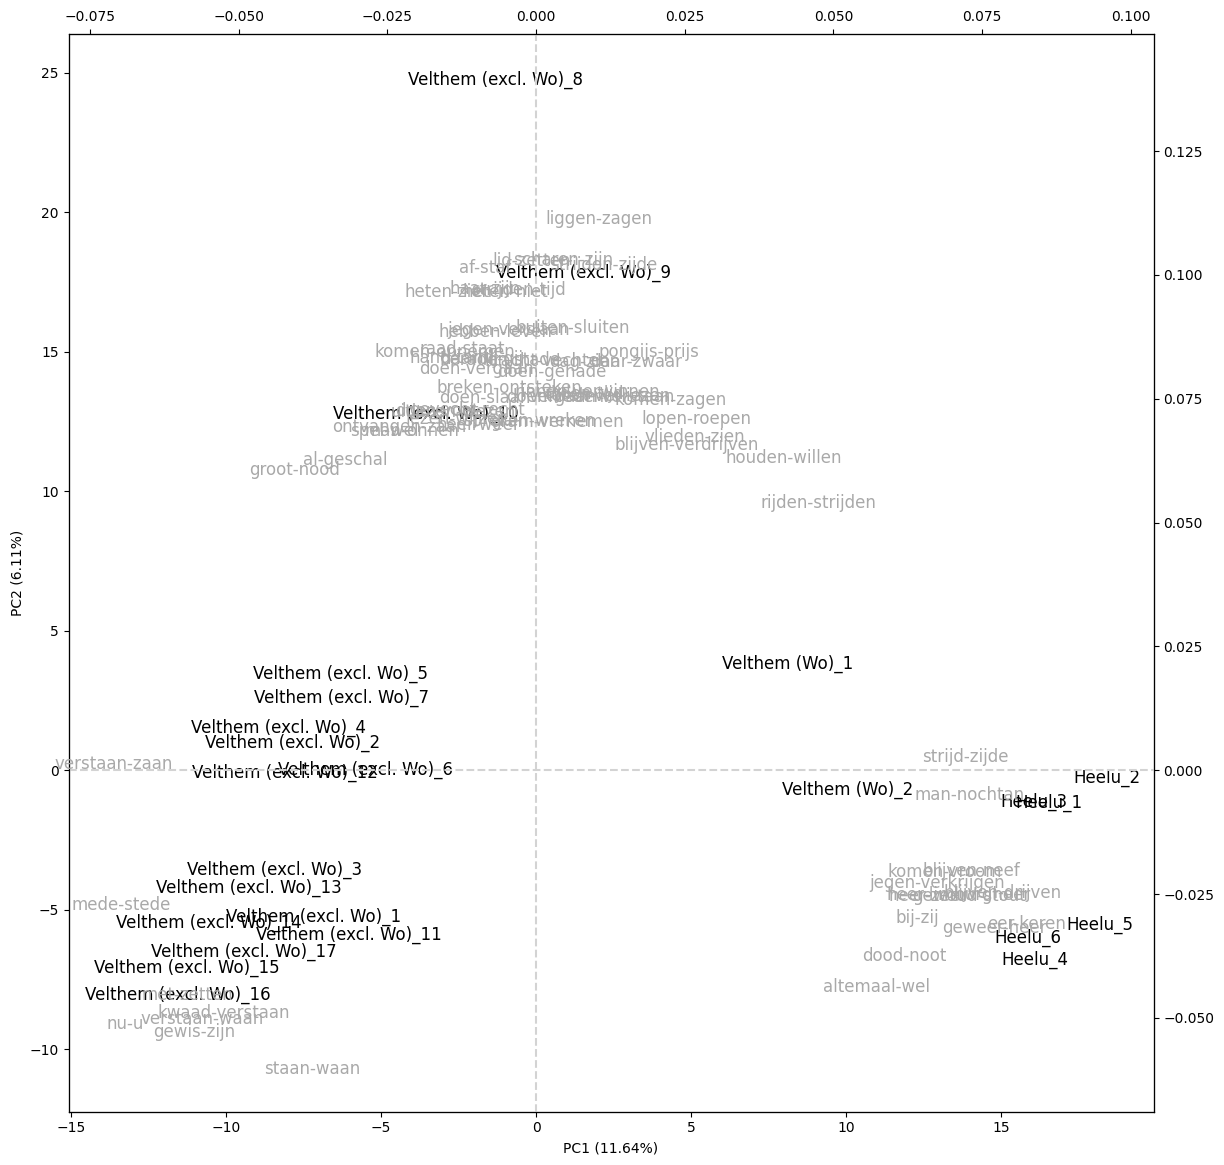

In [9]:
from math import sqrt
def plot_pca(document_proj, loadings, var_exp, labels):
    # first the texts:
    fig, text_ax = plt.subplots(figsize=(14, 14))
    x1, x2 = documents_proj[:, 0], documents_proj[:, 1]
    text_ax.scatter(x1, x2, facecolors='none')
    for p1, p2, label in zip(x1, x2, labels):
        text_ax.text(p1, p2, label, ha='center', va='center', fontsize=12)

    # add variance information to the axis labels:
    text_ax.set_xlabel(f'PC1 ({var_exp[0] * 100:.2f}%)')
    text_ax.set_ylabel(f'PC2 ({var_exp[1] * 100:.2f}%)')
    
    # now the loadings:
    loadings_ax = text_ax.twinx().twiny()
    l1, l2 = loadings[:, 0], loadings[:, 1]
    lc = np.sqrt(l1**2 + l2**2)  #Simply using l1*l2 would eliminate loadings with a high value for PC1 and a low value for PC2. Since mostly PC1 is relevant for the clustering of the three different text groups (see below) this formula was changed 
    m = 70
    top_idxs = lc.argsort()[::-1][:m]
    
    loadings_ax.scatter(l1[top_idxs], l2[top_idxs], facecolors='none');
    for x, y, loading in zip(l1[top_idxs], l2[top_idxs], np.array(vectorizer.get_feature_names_out())[top_idxs]):
        loadings_ax.text(x, y, loading, ha='center', va='center',
                         color='darkgrey', fontsize=12)

    mpl_axes_aligner.align.yaxes(text_ax, 0, loadings_ax, 0)
    mpl_axes_aligner.align.xaxes(text_ax, 0, loadings_ax, 0)
    
    # add lines through origins:
    plt.axvline(0, ls='dashed', c='lightgrey', zorder=0)
    plt.axhline(0, ls='dashed', c='lightgrey', zorder=0);


# fit the pca:
pca = sklearn.decomposition.PCA(n_components=2)
documents_proj = pca.fit_transform(BOW)
loadings = pca.components_.transpose()
var_exp = pca.explained_variance_ratio_

plot_pca(documents_proj, loadings, var_exp, labels)

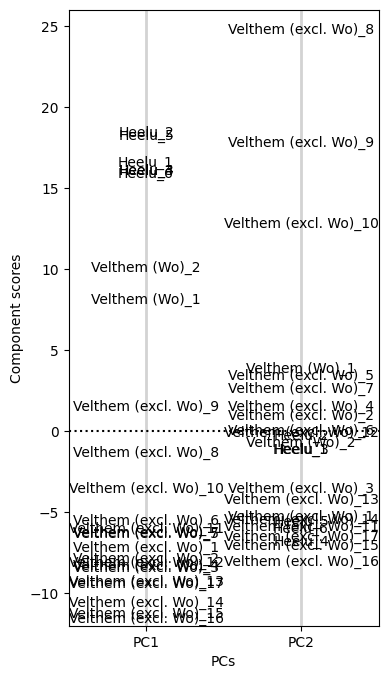

In [10]:
fig, ax = plt.subplots(figsize=(4, 8))

for idx in range(pca.components_.shape[0]):
    ax.axvline(idx, linewidth=2, color='lightgrey')
    for score, title in zip(documents_proj[:, idx], labels):
        ax.text(
            idx, score, title, fontsize=10,
            va='center', ha='center')

ax.axhline(0, ls='dotted', c='black')
ax.set(
    xlim=(-0.5, 1.5), ylim=(-12, 26),
    xlabel='PCs', ylabel='Component scores',
    xticks=[0, 1], xticklabels=["PC1", "PC2"]);

### Loadings PC1

Checking the top positive and negative loadings in relation to PC1:

In [11]:
pca2 = sklearn.decomposition.PCA(n_components=2).fit(BOW)
print(pca.components_.shape)
comps = pca2.components_.transpose()
print(comps.shape)

vocab = vectorizer.get_feature_names_out()
vocab_weights = sorted(zip(comps[:, 0], vocab)) # zip with first PC, at index 0

(2, 1000)
(1000, 2)


In [12]:
print('Negative loadings:')
print('\n'.join(f'{w} -> {s}' for s, w in vocab_weights[:5]))

Negative loadings:
verstaan-zaan -> -0.07095362553986465
mede-stede -> -0.06980188361934081
nu-u -> -0.06915978392850163
horden-voort -> -0.06355930120406646
mede-rijden -> -0.06287638466549476


In [13]:
#Making a dataframe with the frequencies of the top 150 negative pairs for PC1
df_50neg = pd.DataFrame(vocab_weights[:150], columns=['Neg Loadings (PC1)', 'Rhyme Pair'])
SbW = []
WA = []
VP = []

def bigrams2(text):
    bigrams = []
    for i in range(len(text)-1):
        bigrams.append('-'.join((sorted(text[i:i+2])))) #This time rhyme pairs with NOU-P have not been excluded since I will need to calculate relative frequencies of rhyme pairs (& they have already been excluded from vocab_weight so they will be absent from the final Dataframe)
    return bigrams

#Add the frequencies of each rhyme pair
for entry, rhymepairs in zip(segment_df['title'], segment_df['All_rhyme_words']):
    if entry == "rijmkroniek van woeringen":
        SbW += bigrams2(rhymepairs) 
    elif entry == "woeringen-adaptatie":
        WA += bigrams2(rhymepairs) 
    elif entry == "vijfde partie (zonder woeringen-adaptatie)":
        VP += bigrams2(rhymepairs) 
    else:
        print('ERROR')
#print(VP[:10], WA[:10], SbW[:10]) #test
#print(len(df_50neg))

SbW_result = []
WA_result = []
VP_result = []
SbW_result_rel = []
WA_result_rel = []
VP_result_rel = []
for rhymepair in df_50neg['Rhyme Pair']:
    SbW_cnt = 0
    WA_cnt = 0
    VP_cnt = 0
    for entry in SbW:
        if entry == rhymepair:
            SbW_cnt += 1
        else:
            continue
    SbW_result.append(SbW_cnt) #absolute frequency
    SbW_result_rel.append(SbW_cnt / len(SbW)) #Relative frequency (including rhyme pairs with NOU-P)
    for entry in WA:
        if entry == rhymepair:
            WA_cnt += 1
        else:
            continue
    WA_result.append(WA_cnt)
    WA_result_rel.append(WA_cnt / len(WA)) #Relative frequency (including rhyme pairs with NOU-P)
    for entry in VP:
        if entry == rhymepair:
            VP_cnt += 1
        else:
            continue
    VP_result.append(VP_cnt)
    VP_result_rel.append(VP_cnt / len(VP)) #Relative frequency (including rhyme pairs with NOU-P)

df_50neg['Vijfde Partie excl. adaptatie (Abs.)'], df_50neg['Woeringen-adaptatie (Abs.)'], df_50neg['Slag bij Woeringen (Abs.)'] = VP_result, WA_result, SbW_result
df_50neg['Vijfde Partie excl. adaptatie (Rel.)'], df_50neg['Woeringen-adaptatie (Rel.)'], df_50neg['Slag bij Woeringen (Rel.)'] = VP_result_rel, WA_result_rel, SbW_result_rel

pd.set_option('display.max_rows', None)

#highlight rows where a rhyme pair never appears in the Slag bij Woeringen (=blue), but it does appear in the adaptation
def highlight(df):
    return np.tile(np.where((df['Slag bij Woeringen (Abs.)'] == 0) & (df['Woeringen-adaptatie (Abs.)'] != 0) , 'background-color: lightblue', '')[:,None],
                   (1, df.shape[1]))

df_50neg = df_50neg.style.apply(highlight, axis=None)
df_50neg.to_excel("figures/Rhyme_pairs_negative_loadings.xlsx", engine="openpyxl", index=False)
df_50neg

,Neg Loadings (PC1),Rhyme Pair,Vijfde Partie excl. adaptatie (Abs.),Woeringen-adaptatie (Abs.),Slag bij Woeringen (Abs.),Vijfde Partie excl. adaptatie (Rel.),Woeringen-adaptatie (Rel.),Slag bij Woeringen (Rel.)
0,-0.070954,verstaan-zaan,35,2,0,0.001459,0.000709,0.000000
1,-0.069802,mede-stede,177,4,0,0.007379,0.001417,0.000000
2,-0.069160,nu-u,110,5,2,0.004586,0.001772,0.000236
3,-0.063559,horden-voort,20,0,0,0.000834,0.000000,0.000000
4,-0.062876,mede-rijden,48,2,0,0.002001,0.000709,0.000000
5,-0.061348,gaan-waan,25,0,0,0.001042,0.000000,0.000000
6,-0.058653,met-zetten,59,0,0,0.002460,0.000000,0.000000
7,-0.058071,gaan-verstaan,48,1,3,0.002001,0.000354,0.000354
8,-0.057999,deze-wijzen,31,0,0,0.001292,0.000000,0.000000
9,-0.057551,gewis-zijn,14,0,0,0.000584,0.000000,0.000000


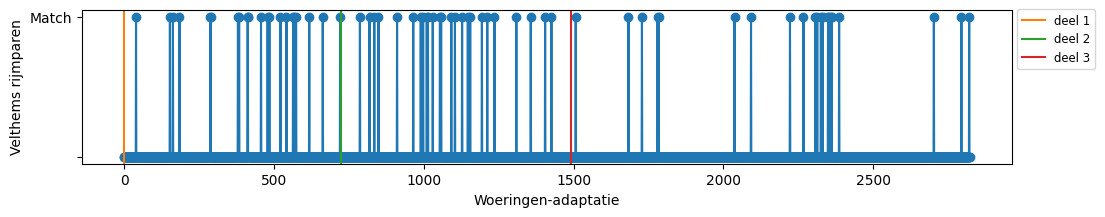

In [14]:
#Visualisation of where the rhyme pairs below occur within the adaptation
important_matches = ['verstaan-zaan', 'mede-stede', 'mede-rijden', 'dan-man', 'niet-verdriet', 'heer-meer', 'groot-nood', 
                     'dat-zijn', 'daar-naar', 'albloed-groot', 'zijn-zijn', 'alzo-toe', 'das-zijn', 'raad-verstaan', 
                     'jaar-voorwaar', 'aan-dan', 'godweet-reden', 'alzo-toen', 'bekennen-land', 'geschieden-verdriet', 
                     'echt-recht', 'sake-sprake', 'doen-zaan', 'hij-vernemen', 'waan-zaan']
results=[]
for rhymepair in WA:
    if rhymepair in important_matches:
        results.append(1)
    elif rhymepair not in important_matches:
        results.append(0)
    else:
        print("ERROR!")
        
#plot graph
import matplotlib.pyplot as plt

x = range(len(WA))
y= results

plt.figure(figsize=(12,2))
plt.plot(x, y, marker='o')
plt.yticks([0, 1], ["", "Match"])
plt.xlabel("Woeringen-adaptatie")
plt.ylabel("Velthems rijmparen")

#plot the start of part 1, part 2 and part 3 of the Woeringen-adaptation
for idx, v in enumerate(WA): #Velthem's text
    if '''vermaard-waard''' in v: # start of Velthem's first adaptation segment
        start_part1 = idx
    if '''gehengen-vermogen''' in v: # start of Velthem's second adaptation segment   
        start_part2 = idx
    if '''--geliggen''' in v: # start of Velthem's third adaptation segment   
        start_part3 = idx
plt.axvline(start_part1, color='C1', label="deel 1")
plt.axvline(start_part2, color='C2', label="deel 2")
plt.axvline(start_part3, color='C3', label="deel 3")

plt.legend(loc='upper right', fontsize = 'small', bbox_to_anchor=(1.096, 1.04))

plt.show()

In [15]:
#creating segments consisting of the rhyme words of the entire Vijfde Partie
segment_Fifth_Part = segment(corpus_df.iloc[[1]], rhyme_only=True, incl_pos=False, segment_length=2133)
segment_Fifth_Part

100%|██████████| 1/1 [00:00<00:00, 71.22it/s]


,title,author,segment-idx,All_rhyme_words
0,vijfde partie,Velthem,1,"[j, doen, groot, innocent, consent, NOU-P, bed..."
1,vijfde partie,Velthem,2,"[mede, binden, vinden, land, hand, mede, blohe..."
2,vijfde partie,Velthem,3,"[ontvangen, gaan, dat, stad, ontvangen, na, we..."
3,vijfde partie,Velthem,4,"[al, geval, zesentwintig, man, aan, koen, misd..."
4,vijfde partie,Velthem,5,"[landvrede, koeler, heer, zaan, staan, geven, ..."
5,vijfde partie,Velthem,6,"[schat, dat, gehend, en, varen, baren, zaan, w..."
6,vijfde partie,Velthem,7,"[benemen, komen, maag, klagen, heer, keren, NO..."
7,vijfde partie,Velthem,8,"[zijn, zijn, schaar, mislaten, niet, dragen, s..."
8,vijfde partie,Velthem,9,"[dat, dan, aan, zevenenveertig, sedert, weder,..."
9,vijfde partie,Velthem,10,"[goed, vier, schier, zijn, dat, NOU-P, zekerli..."


In [83]:
#Visualisation of specific bigram appearances within the entire Vijfde Partie.
segment_Fifth_Part = segment(corpus_df.iloc[[1]], rhyme_only=True, incl_pos=False, segment_length=2133)
VP_FULL = []
for entry, rhymepairs in zip(segment_Fifth_Part['title'], segment_Fifth_Part['All_rhyme_words']):
    if entry == "vijfde partie":
        VP_FULL += bigrams2(rhymepairs)  
    else:
        print('ERROR')

def bigram_plot(important_matches):
    results=[]
    for rhymepair in VP_FULL:
        if rhymepair in important_matches:
            results.append(1)
        elif rhymepair not in important_matches:
            results.append(0)
        else:
            print("ERROR!")

    #plot graph
    import matplotlib.pyplot as plt

    x = range(len(VP_FULL))
    y= results

    plt.figure(figsize=(12,2))
    plt.plot(x, y, marker='o')
    plt.yticks([0, 1], ["", "Match"])
    plt.xlabel("Vijfde Partie")
    plt.ylabel(f"{important_matches[0]}")

    #plot the start of part 1, part 2 and part 3 of the Woeringen-adaptation
    for idx, v in enumerate(VP_FULL): #Velthem's text
        if '''vermaard-waard''' in v: # start of Velthem's first adaptation segment
            start_part1 = idx
        if '''gehengen-vermogen''' in v: # start of Velthem's second adaptation segment   
            start_part2 = idx
        if '''--geliggen''' in v: # start of Velthem's third adaptation segment   
            start_part3 = idx

    plt.axvline(start_part1, color='C1', label="deel 1")
    plt.axvline(start_part2, color='C2', label="deel 2")
    plt.axvline(start_part3, color='C3', label="deel 3")
    plt.axvline(3562, color='C1') #end part 1
    plt.axvline(8340, color='C2') #end part 2
    plt.axvline(9803, color='C3') #end part 3
    
    plt.axvline(12485, color='C6', label="Gulden-\nsporenslag") #beginning Guldensporenslag
    plt.axvline(16344, color='C6') #end Guldensporenslag
    
    
    plt.legend(loc='upper right', fontsize = 'small', bbox_to_anchor=(1.12, 1.04))

    plt.show()

100%|██████████| 1/1 [00:00<00:00, 57.02it/s]


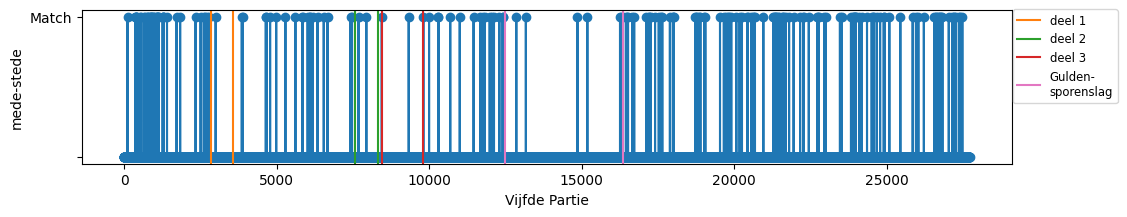

In [84]:
bigram_plot(important_matches = ['mede-stede'])

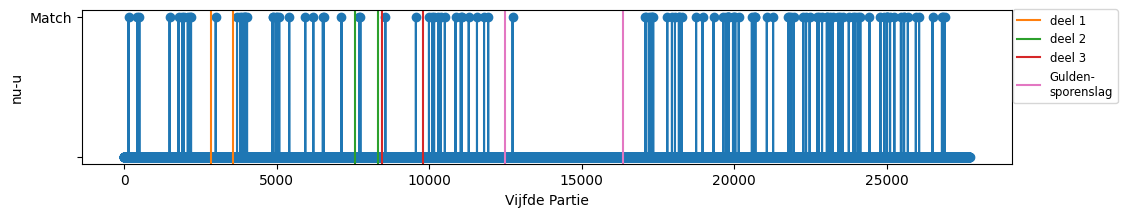

In [85]:
bigram_plot(important_matches = ['nu-u'])

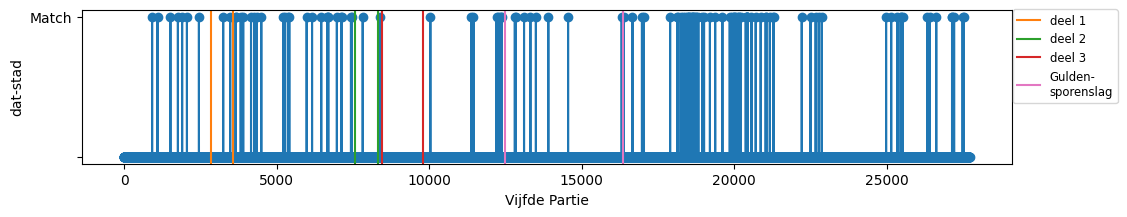

In [86]:
bigram_plot(important_matches = ['dat-stad'])

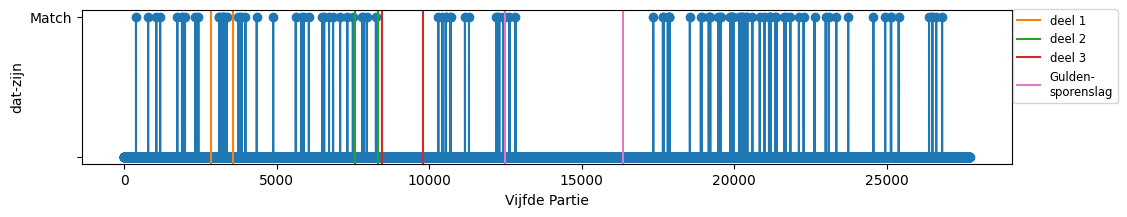

In [87]:
bigram_plot(important_matches = ['dat-zijn'])

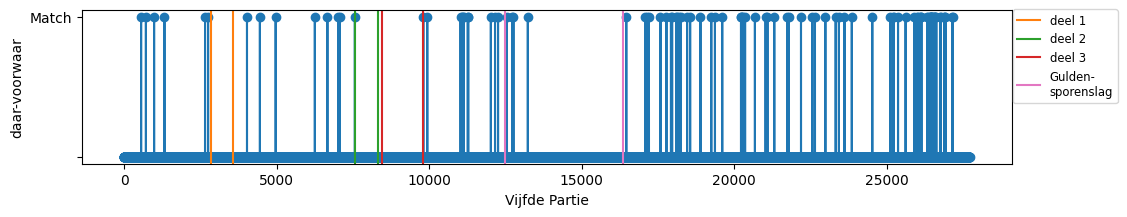

In [88]:
bigram_plot(important_matches = ['daar-voorwaar'])

In [159]:
print('Positive loadings:')
print('\n'.join(f'{w} -> {s}' for s, w in vocab_weights[-5:]))

Positive loadings:
man-nochtan -> 0.07292240909337645
blijven-neef -> 0.07323541598764965
geweer-heer -> 0.07714058433168516
blijven-drijven -> 0.07843288764981618
eer-keren -> 0.08244760834353097


In [160]:
#Making a dataframe with the frequencies of the top 100 positive pairs for PC1
df_50pos = pd.DataFrame(vocab_weights[-150:], columns=['Pos Loadings (PC1)', 'Rhyme Pair'])
SbW = []
WA = []
VP = []

def bigrams2(text):
    bigrams = []
    for i in range(len(text)-1):
        bigrams.append('-'.join((sorted(text[i:i+2])))) #This time rhyme pairs with NOU-P have not been excluded since I will need to calculate relative frequencies of rhyme pairs (& they have already been excluded from vocab_weight so they will be absent from the final Dataframe)
    return bigrams

#Add the frequencies of each rhyme pair
for entry, rhymepairs in zip(segment_df['title'], segment_df['All_rhyme_words']):
    if entry == "rijmkroniek van woeringen":
        SbW += bigrams2(rhymepairs) 
    elif entry == "woeringen-adaptatie":
        WA += bigrams2(rhymepairs) 
    elif entry == "vijfde partie (zonder woeringen-adaptatie)":
        VP += bigrams2(rhymepairs) 
    else:
        print('ERROR')
#print(VP[:10], WA[:10], SbW[:10]) #test
#print(len(df_50pos))

SbW_result = []
WA_result = []
VP_result = []
SbW_result_rel = []
WA_result_rel = []
VP_result_rel = []
for rhymepair in df_50pos['Rhyme Pair']:
    SbW_cnt = 0
    WA_cnt = 0
    VP_cnt = 0
    for entry in SbW:
        if entry == rhymepair:
            SbW_cnt += 1
        else:
            continue
    SbW_result.append(SbW_cnt) #absolute frequency
    SbW_result_rel.append(SbW_cnt / len(SbW)) #Relative frequency (including rhyme pairs with NOU-P)
    for entry in WA:
        if entry == rhymepair:
            WA_cnt += 1
        else:
            continue
    WA_result.append(WA_cnt)
    WA_result_rel.append(WA_cnt / len(WA)) #Relative frequency (including rhyme pairs with NOU-P)
    for entry in VP:
        if entry == rhymepair:
            VP_cnt += 1
        else:
            continue
    VP_result.append(VP_cnt)
    VP_result_rel.append(VP_cnt / len(VP)) #Relative frequency (including rhyme pairs with NOU-P)

df_50pos['Vijfde Partie z/ adapt (Abs.)'], df_50pos['Woeringen-adaptatie (Abs.)'], df_50pos['Slag bij Woeringen (Abs.)'] = VP_result, WA_result, SbW_result
df_50pos['Vijfde Partie z/ adapt (Rel.)'], df_50pos['Woeringen-adaptatie (Rel.)'], df_50pos['Slag bij Woeringen (Rel.)'] = VP_result_rel, WA_result_rel, SbW_result_rel
df_50pos = df_50pos.iloc[::-1]

#highlight rows where a rhyme pair never appears in the Vijfde Partie without the adaptation (=green)
def highlight(df):
    return np.tile(np.where((df['Vijfde Partie z/ adapt (Abs.)'] == 0) & (df['Woeringen-adaptatie (Abs.)'] != 0), 'background-color: lightgreen', '')[:,None],
                   (1, df.shape[1]))

df_50pos = df_50pos.style.apply(highlight, axis=None)
df_50pos.to_excel("figures/Rhyme_pairs_positive_loadings.xlsx", engine="openpyxl", index=False)
df_50pos

,Pos Loadings (PC1),Rhyme Pair,Vijfde Partie z/ adapt (Abs.),Woeringen-adaptatie (Abs.),Slag bij Woeringen (Abs.),Vijfde Partie z/ adapt (Rel.),Woeringen-adaptatie (Rel.),Slag bij Woeringen (Rel.)
149,0.082448,eer-keren,1,3,22,0.000042,0.001063,0.002599
148,0.078433,blijven-drijven,4,5,28,0.000167,0.001772,0.003307
147,0.077141,geweer-heer,1,2,22,0.000042,0.000709,0.002599
146,0.073235,blijven-neef,0,2,13,0.000000,0.000709,0.001536
145,0.072922,man-nochtan,1,3,10,0.000042,0.001063,0.001181
144,0.072782,gewoud-stout,1,3,12,0.000042,0.001063,0.001417
143,0.072204,strijd-zijde,16,5,37,0.000667,0.001772,0.004370
142,0.071097,heer-limburgheer,0,1,7,0.000000,0.000354,0.000827
141,0.068657,komen-vroom,2,2,12,0.000083,0.000709,0.001417
140,0.067491,jegen-verkrijgen,0,0,8,0.000000,0.000000,0.000945


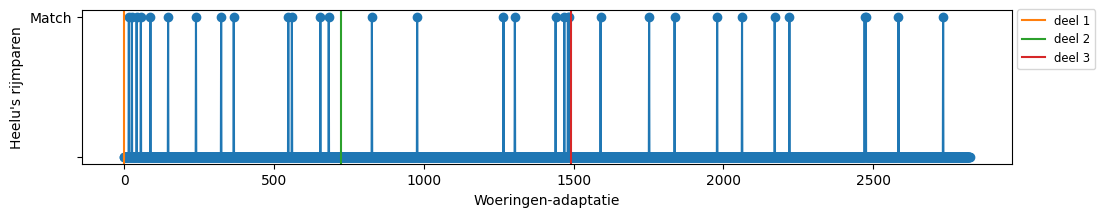

In [188]:
#Visualisation of where these matches occur within the adaptation
important_matches = ['blijven-neef', 'heer-limburgheer', 'duren-voeren', 'viseren-weren', 'geslacht-rechte', 'hanteren-verweren',
                     'mogen-tijgen', 'broeder-moeder', 'brengen-kracht', 'mat-stad', 'gevellen-tellen', 'hertog-mogen', 
                     'eren-keren', 'avontuur-duren', 'reis-vrees', 'manier-tornieren', 'taal-wezenmaal', 'meten-stad', 
                     'dag-gewag', 'logeren-weren', 'leiden-verbeiden', 'strijd-zeer', 'strijd-wel', 'baron-zoen', 'vlieden-zijn']
results=[]
for rhymepair in WA:
    if rhymepair in important_matches:
        results.append(1)
    elif rhymepair not in important_matches:
        results.append(0)
    else:
        print("ERROR!")
        
#plot graph
import matplotlib.pyplot as plt

x = range(len(WA))
y= results

plt.figure(figsize=(12,2))
plt.plot(x, y, marker='o')
plt.yticks([0, 1], ["", "Match"])
plt.xlabel("Woeringen-adaptatie")
plt.ylabel("Heelu's rijmparen")

#plot the start of part 1, part 2 and part 3 of the Woeringen-adaptation
for idx, v in enumerate(WA): #Velthem's text
    if '''vermaard-waard''' in v: #start of Velthem's first adaptation segment
        start_part1 = idx
    if '''gehengen-vermogen''' in v: #start of Velthem's second adaptation segment   
        start_part2 = idx
    if '''--geliggen''' in v: #start of Velthem's third adaptation segment   
        start_part3 = idx
plt.axvline(start_part1, color='C1', label="deel 1")
plt.axvline(start_part2, color='C2', label="deel 2")
plt.axvline(start_part3, color='C3', label="deel 3")

plt.legend(loc='upper right', fontsize = 'small', bbox_to_anchor=(1.096, 1.04))

plt.show()

### Loadings PC2

Check the top positive and negative loadings in relation to PC2:

In [433]:
vocab = vectorizer.get_feature_names_out()
vocab_weights_pc2 = sorted(zip(comps[:, 1], vocab)) # zip with second PC, at index 1

In [434]:
print('Negative loadings:')
print('\n'.join(f'{w} -> {s}' for s, w in vocab_weights_pc2[:5]))

Negative loadings:
staan-waan -> -0.058867331927924545
daar-openbaar -> -0.05826877700488861
eer-meer -> -0.05527845474022715
nu-u -> -0.05260604629931625
gewis-zijn -> -0.05107903134737927


In [435]:
print('Positive loadings:')
print('\n'.join(f'{w} -> {s}' for s, w in vocab_weights_pc2[-5:]))

Positive loadings:
strijden-zijde -> 0.10175831343269612
af-staf -> 0.10270819418024343
scharen-zijn -> 0.10276590396284657
lid-zetten -> 0.10380702112143073
liggen-zagen -> 0.1119937522407782


## 3.2: PCA-plot based on function words

In [251]:
def segment(work_df, rhyme_only=True, incl_lemma=True, incl_pos=False, segment_length = 2000, min_length=1364):        
    if not (incl_pos or incl_lemma):
        raise ValueError('incl_lemma OR incl_pos must be set to True')

    segments = []

    for _, row in tqdm(list(work_df.iterrows())):
        if rhyme_only:
            #"if verse" was added to skip empty verse lines (lacuna). In the parse_xml function empty lists [] were yielded
            #so that verse counts remained accurate
            text = [verse[-1] for verse in row['lines_lemma_and_pos'] if verse]
        else:
            text = [item for sublist in row['lines_lemma_and_pos'] for item in sublist]
        
        if incl_lemma and incl_pos:
            text = ['@'.join(p) for p in text]
        elif incl_lemma:
            text = [p[0] for p in text]
            #text = [' '.join(text)]
        else:
            text = [p[1] for p in text]

        meta = [row['title'], row['author']]
        
        if segment_length:
            if len(text) < segment_length:
                continue
            si, ei, idx = 0, segment_length, 1
            while ei < len(text):
                segments.append(meta + [idx, ' '.join(text[si:ei])]) #Concatenate the words back into a string
                idx += 1
                si += segment_length
                ei += segment_length
        else:
            if len(text) >= min_length:
                segments.append(meta + [0, text])
                

    return pd.DataFrame(segments, columns=['title', 'author', 'segment-idx', 'all_text'])

In [252]:
#Word length of Woeringen adaptation (for optimal segmentation)
#len(corpus_df.iloc[2]['lines_lemmatized'])
len(' '.join(corpus_df.iloc[2]['lines_lemmatized']).split())

16498

In [253]:
#Segment all text within the corpus, not just the function words (As a result there are many more segments in comparison to the rhyme analysis)
segment_df_all = segment(corpus_df.iloc[[0,2, 3]], rhyme_only=False, incl_pos=False, segment_length=3297)
segment_df_all.head()

100%|██████████| 3/3 [00:00<00:00, 28.20it/s]


,title,author,segment-idx,all_text
0,rijmkroniek van woeringen,Heelu,1,vrouwe NOU-P van NOU-P die zeker hebben van NO...
1,rijmkroniek van woeringen,Heelu,2,zijn leen doen ne blijven oorlog ook ne geen i...
2,rijmkroniek van woeringen,Heelu,3,en NOU-P worden een toernooi nemen te dat toer...
3,rijmkroniek van woeringen,Heelu,4,roef doen openbaren doen dies worden gewaar va...
4,rijmkroniek van woeringen,Heelu,5,zwaard bekorten willen wie dat worden dat land...


In [254]:
segment_df_all.tail(10)

,title,author,segment-idx,all_text
53,vijfde partie (zonder woeringen-adaptatie),Velthem,35,dat liggen zijn daar omtrent als dit die herto...
54,vijfde partie (zonder woeringen-adaptatie),Velthem,36,wil hebben op NOU-P te stormen in de zelf ston...
55,vijfde partie (zonder woeringen-adaptatie),Velthem,37,coninx man alzo die van NOU-P spreken re toege...
56,vijfde partie (zonder woeringen-adaptatie),Velthem,38,ik NOU-P dit zachten verliezen mijn geest al z...
57,vijfde partie (zonder woeringen-adaptatie),Velthem,39,het en oriënt en aquilon en occident NOU-P het...
58,vijfde partie (zonder woeringen-adaptatie),Velthem,40,verstandenis daar aan deze spiegel te verstaan...
59,vijfde partie (zonder woeringen-adaptatie),Velthem,41,in een verdriet slaan dat zij zo veel hebben d...
60,vijfde partie (zonder woeringen-adaptatie),Velthem,42,achterste zullen zijn - NOU-P die heer van hem...
61,vijfde partie (zonder woeringen-adaptatie),Velthem,43,dan geven uit dat zesde dan zullen die gestich...
62,vijfde partie (zonder woeringen-adaptatie),Velthem,44,wil als zij wel weten zo waren onrecht in loen...


In [255]:
import sklearn.feature_extraction.text as text

# initialize vectorizer
vectorizer = text.CountVectorizer(max_features=200, token_pattern=r"(?u)\b[\w-]+\b")
#regex ensures words are properly tokenised.
v_documents = vectorizer.fit_transform(segment_df_all['all_text']).toarray()

print(v_documents.shape)
print(vectorizer.get_feature_names_out()[:5])   #The most frequent features in the text are function words, they are used more often than content words.

#Save the top 200 most frequent words and save as txt file
top_200_features = ''
for entry in list(vectorizer.get_feature_names_out()):
    top_200_features += entry + '\n'
top_200_features = top_200_features.strip()

with open('data/200_MFW.txt', 'w', encoding='utf-8') as text_file:
    text_file.write(top_200_features)

(63, 200)
['aan' 'achter' 'af' 'al' 'aldus']


Load the function words txt file:

In [256]:
#The top 200 most frequent word list has been manually edited so that only function words remain:
# untangle
vocab = [l.strip() for l in open('data/Function_words_list.txt', encoding='utf-8')
         if not l.startswith('#') and l.strip()]
print(len(vocab)) #87 function words remain
print(vocab)

87
['aan', 'achter', 'af', 'al', 'aldus', 'als', 'alzo', 'ander', 'beide', 'bij', 'binnen', 'daar', 'daarna', 'dan', 'dat', 'de', 'des', 'deze', 'die', 'dies', 'dit', 'door', 'dus', 'een', 'elk', 'en', 'enig', 'er', 'geen', 'gij', 'haar', 'hebben', 'het', 'hier', 'hij', 'hoe', 'iet', 'ik', 'in', 'jegen', 'kunnen', 'maar', 'mede', 'men', 'met', 'mijn', 'moeten', 'mogen', 'na', 'naar', 'ne', 'nie', 'niet', 'noch', 'nochtan', 'nog', 'nu', 'of', 'om', 'onder', 'ons', 'ook', 'op', 'over', 'te', 'ten', 'ter', 'toe', 'toen', 'tot', 'tussen', 'u', 'uit', 'van', 'voor', 'waar', 'want', 'wat', 'wel', 'wij', 'wil', 'willen', 'worden', 'zij', 'zijn', 'zonder', 'zullen']


In [257]:
#Transform the data into a vector space model, but this time use the Function Words list as the vocabulary
import sklearn.preprocessing as preprocessing

vectorizer = text.CountVectorizer(token_pattern=r"(?u)\b\w+\b", vocabulary=vocab)
v_documents = vectorizer.fit_transform(segment_df_all['all_text']).toarray()
v_documents = preprocessing.normalize(v_documents.astype(float), norm='l1')
scaler = preprocessing.StandardScaler()
v_documents = scaler.fit_transform(v_documents)

print(f'N={v_documents.shape[0]} documents with '
      f'V={v_documents.shape[1]} features.')

N=63 documents with V=87 features.


In [258]:
#Visualise the BOW as a dataframe
v_documents_df = pd.DataFrame(v_documents, columns = vectorizer.get_feature_names_out())

print(len(v_documents)) 
print(len(v_documents) == len(segment_df_all)) #sanity check
print(len(v_documents_df))
v_documents_df.head()

63
True
63


,aan,achter,af,al,aldus,als,alzo,ander,beide,bij,...,wat,wel,wij,wil,willen,worden,zij,zijn,zonder,zullen
0,-0.008557,0.470106,0.533174,0.478364,-0.922174,-0.830816,0.279869,-0.791875,2.207433,1.737783,...,-1.287634,-0.921850,-0.758619,-0.012571,2.445523,-0.889985,-0.034819,-0.510806,0.170307,-0.447291
1,-0.280880,-0.503240,1.350102,0.349024,-0.908015,0.249763,-0.036257,-1.265820,1.446903,1.341860,...,-1.281619,-0.891210,-0.943956,-0.521929,-0.370256,1.057210,-1.077630,-0.695377,-0.682989,-0.431344
2,1.460926,-1.004377,0.227080,1.071492,-0.941326,-1.020159,-0.614576,-0.838162,1.859447,1.508819,...,-1.295770,-1.153333,-0.943956,-1.051672,1.261293,-0.346709,0.378189,-0.266158,1.543551,-0.205099
3,0.028420,-0.505686,1.335024,1.898693,0.186876,-0.953773,1.011420,0.245039,0.614916,1.783777,...,-0.660934,-0.304740,-0.567855,-1.051672,-0.793274,-0.067444,2.180179,-0.726618,1.132232,-0.553211
4,-1.208193,0.027706,0.911775,0.467834,-0.128327,-1.666278,0.557142,-1.228036,1.237603,0.952353,...,-1.272321,0.181014,-0.943956,-1.051672,0.828602,0.694950,-0.858052,-0.892724,0.965442,-0.203492


In [259]:
labels = []
for entry, nr in zip(segment_df_all['title'], segment_df_all['segment-idx']):
    if entry == "rijmkroniek van woeringen":
        labels.append(f"Heelu_{nr}")
    elif entry == "woeringen-adaptatie":
        labels.append(f"Velthem (Wo)_{nr}")
    elif entry == "vijfde partie (zonder woeringen-adaptatie)":
        labels.append(f"Velthem (excl. Wo)_{nr}")
labels
len(labels)

63

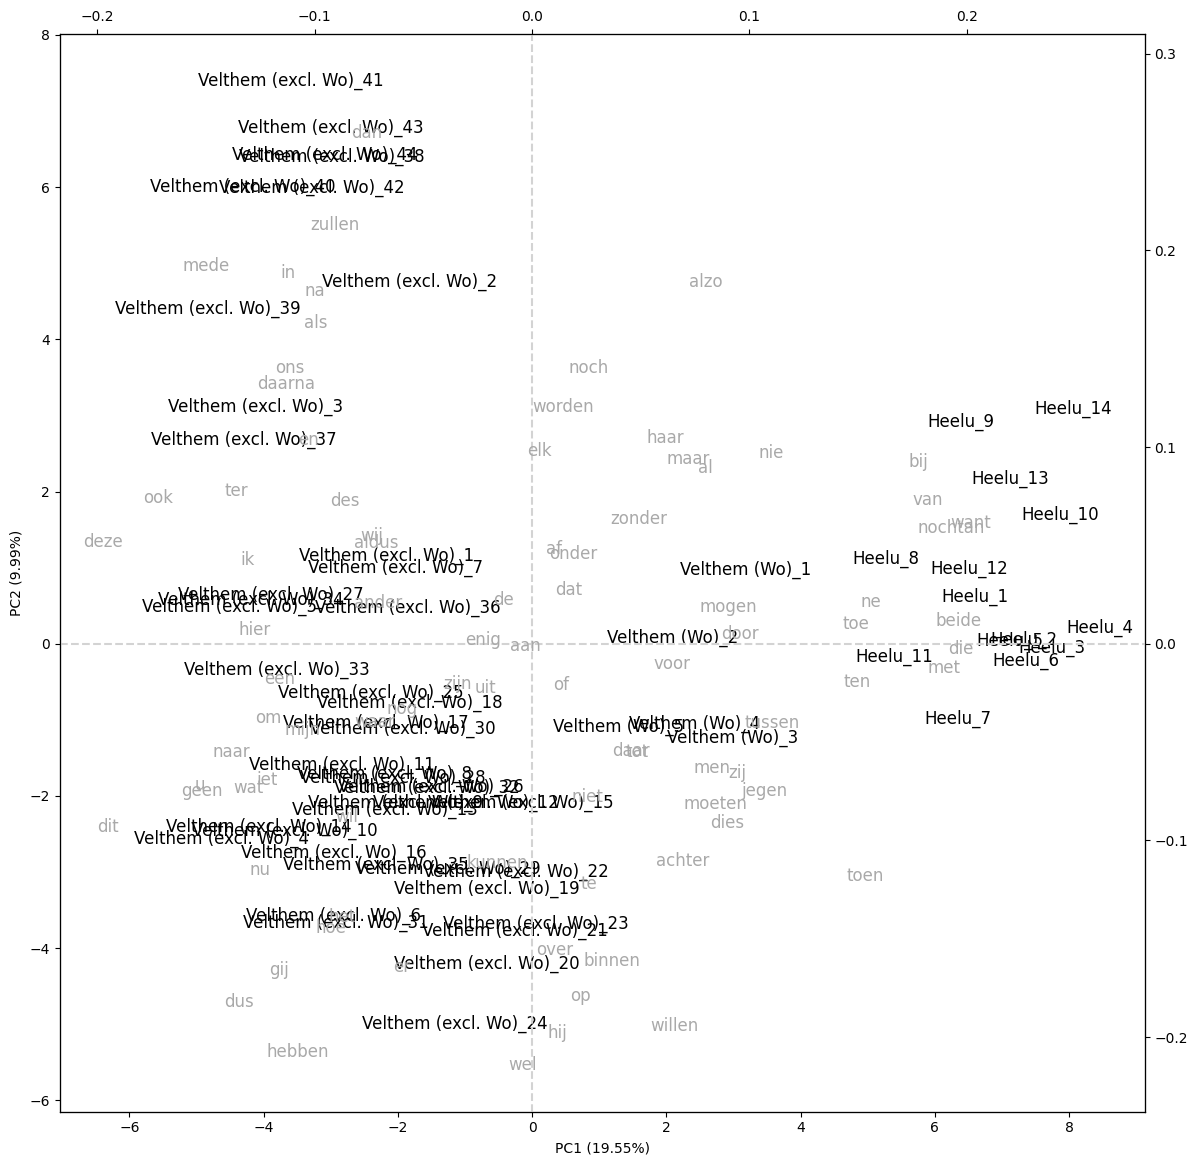

In [260]:
# fit the pca:
pca = sklearn.decomposition.PCA(n_components=2)
documents_proj = pca.fit_transform(v_documents)
loadings = pca.components_.transpose()
var_exp = pca.explained_variance_ratio_

#Edit the plot_pca function so all loadings will be plotted
def plot_pca(document_proj, loadings, var_exp, labels):
    # first the texts:
    fig, text_ax = plt.subplots(figsize=(14, 14))
    x1, x2 = documents_proj[:, 0], documents_proj[:, 1]
    text_ax.scatter(x1, x2, facecolors='none')
    for p1, p2, label in zip(x1, x2, labels):
        text_ax.text(p1, p2, label, ha='center', va='center', fontsize=12)

    # add variance information to the axis labels:
    text_ax.set_xlabel(f'PC1 ({var_exp[0] * 100:.2f}%)')
    text_ax.set_ylabel(f'PC2 ({var_exp[1] * 100:.2f}%)')
    
    # now the loadings:
    loadings_ax = text_ax.twinx().twiny()
    l1, l2 = loadings[:, 0], loadings[:, 1]
    lc = np.sqrt(l1**2 + l2**2)
    m = 87
    top_idxs = lc.argsort()[::-1][:m]
    
    loadings_ax.scatter(l1[top_idxs], l2[top_idxs], facecolors='none');
    for x, y, loading in zip(l1[top_idxs], l2[top_idxs], np.array(vectorizer.get_feature_names_out())[top_idxs]):
        loadings_ax.text(x, y, loading, ha='center', va='center',
                         color='darkgrey', fontsize=12)

    mpl_axes_aligner.align.yaxes(text_ax, 0, loadings_ax, 0)
    mpl_axes_aligner.align.xaxes(text_ax, 0, loadings_ax, 0)
    
    # add lines through origins:
    plt.axvline(0, ls='dashed', c='lightgrey', zorder=0)
    plt.axhline(0, ls='dashed', c='lightgrey', zorder=0);
plot_pca(documents_proj, loadings, var_exp, labels)

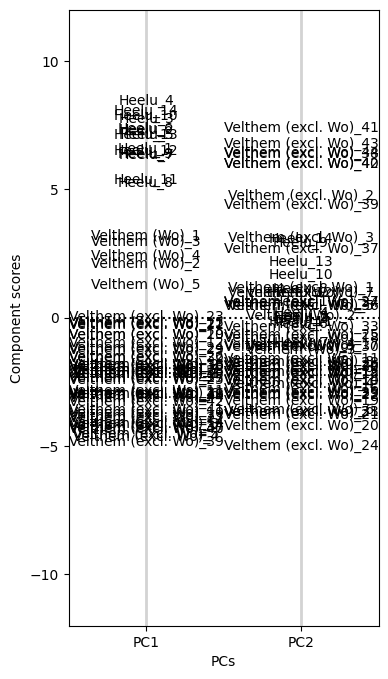

In [261]:
fig, ax = plt.subplots(figsize=(4, 8))

for idx in range(pca.components_.shape[0]):
    ax.axvline(idx, linewidth=2, color='lightgrey')
    for score, title in zip(documents_proj[:, idx], labels):
        ax.text(
            idx, score, title, fontsize=10,
            va='center', ha='center')

ax.axhline(0, ls='dotted', c='black')
ax.set(
    xlim=(-0.5, 1.5), ylim=(-12, 12),
    xlabel='PCs', ylabel='Component scores',
    xticks=[0, 1], xticklabels=["PC1", "PC2"]);

### Loadings PC1

Checking the top positive and negative loadings in relation to PC1:

In [262]:
pca2 = sklearn.decomposition.PCA(n_components=2).fit(v_documents)
print(pca2.components_.shape)
comps = pca2.components_.transpose()
print(comps.shape)

vocab = vectorizer.get_feature_names_out()
vocab_weights = sorted(zip(comps[:, 0], vocab)) # zip with first PC, at index 0

(2, 87)
(87, 2)


In [263]:
print('Negative loadings:')
print('\n'.join(f'{w} -> {s}' for s, w in vocab_weights[:5]))

Negative loadings:
deze -> -0.19738626071725435
dit -> -0.19513828246181464
ook -> -0.1720605539925507
u -> -0.15276088987720376
geen -> -0.1520869009703815


In [264]:
#Making a dataframe with the frequencies of the top 10 negative function words for PC1
df_10neg = pd.DataFrame(vocab_weights[:10], columns=['Neg Loadings (PC1)', 'Function Word'])
SbW = []
WA = []
VP = []

#Add all text to a list
for entry, text in zip(segment_df_all['title'], segment_df_all['all_text']):
    if entry == "rijmkroniek van woeringen":
        SbW += text.split() 
    elif entry == "woeringen-adaptatie":
        WA += text.split()
    elif entry == "vijfde partie (zonder woeringen-adaptatie)":
        VP += text.split()
    else:
        print('ERROR')
#print(VP[:10], WA[:10], SbW[:10]) #test

SbW_result = []
WA_result = []
VP_result = []
SbW_result_rel = []
WA_result_rel = []
VP_result_rel = []
for FunctionWord in df_10neg['Function Word']:
    SbW_cnt = 0
    WA_cnt = 0
    VP_cnt = 0
    for entry in SbW:
        if entry == FunctionWord:
            SbW_cnt += 1
        else:
            continue
    SbW_result.append(SbW_cnt) #absolute frequency
    SbW_result_rel.append(SbW_cnt / len(SbW)) #Relative frequency (divided by all words, not only function words)
    for entry in WA:
        if entry == FunctionWord:
            WA_cnt += 1
        else:
            continue
    WA_result.append(WA_cnt)
    WA_result_rel.append(WA_cnt / len(WA)) #Relative frequency 
    for entry in VP:
        if entry == FunctionWord:
            VP_cnt += 1
        else:
            continue
    VP_result.append(VP_cnt)
    VP_result_rel.append(VP_cnt / len(VP)) #Relative frequency

df_10neg['Vijfde Partie z/ adapt (Abs.)'], df_10neg['Woeringen-adaptatie (Abs.)'], df_10neg['Slag bij Woeringen (Abs.)'] = VP_result, WA_result, SbW_result
df_10neg['Vijfde Partie z/ adapt (Rel.)'], df_10neg['Woeringen-adaptatie (Rel.)'], df_10neg['Slag bij Woeringen (Rel.)'] = VP_result_rel, WA_result_rel, SbW_result_rel

pd.set_option('display.max_rows', None)

#highlight rows where a function word never appears in the Slag bij Woeringen (=blue), but it does appear in the adaptation
def highlight(df):
    return np.tile(np.where((df['Slag bij Woeringen (Abs.)'] == 0) & (df['Woeringen-adaptatie (Abs.)'] != 0) , 'background-color: lightblue', '')[:,None],
                   (1, df.shape[1]))

df_10neg = df_10neg.style.apply(highlight, axis=None)
df_10neg.to_excel("figures/Function_words_negative_loadings.xlsx", engine="openpyxl", index=False)
df_10neg

,Neg Loadings (PC1),Function Word,Vijfde Partie z/ adapt (Abs.),Woeringen-adaptatie (Abs.),Slag bij Woeringen (Abs.),Vijfde Partie z/ adapt (Rel.),Woeringen-adaptatie (Rel.),Slag bij Woeringen (Rel.)
0,-0.197386,deze,1237,97,115,0.008527,0.005884,0.002491
1,-0.195138,dit,1120,83,38,0.007721,0.005035,0.000823
2,-0.172061,ook,1087,97,112,0.007493,0.005884,0.002426
3,-0.152761,u,621,41,50,0.004281,0.002487,0.001083
4,-0.152087,geen,486,36,34,0.003350,0.002184,0.000737
5,-0.150184,mede,568,51,48,0.003915,0.003094,0.001040
6,-0.138439,naar,173,13,1,0.001193,0.000789,0.000022
7,-0.136233,ter,423,38,58,0.002916,0.002305,0.001257
8,-0.134651,dus,610,61,38,0.004205,0.003700,0.000823
9,-0.131088,ik,1547,81,275,0.010664,0.004914,0.005958


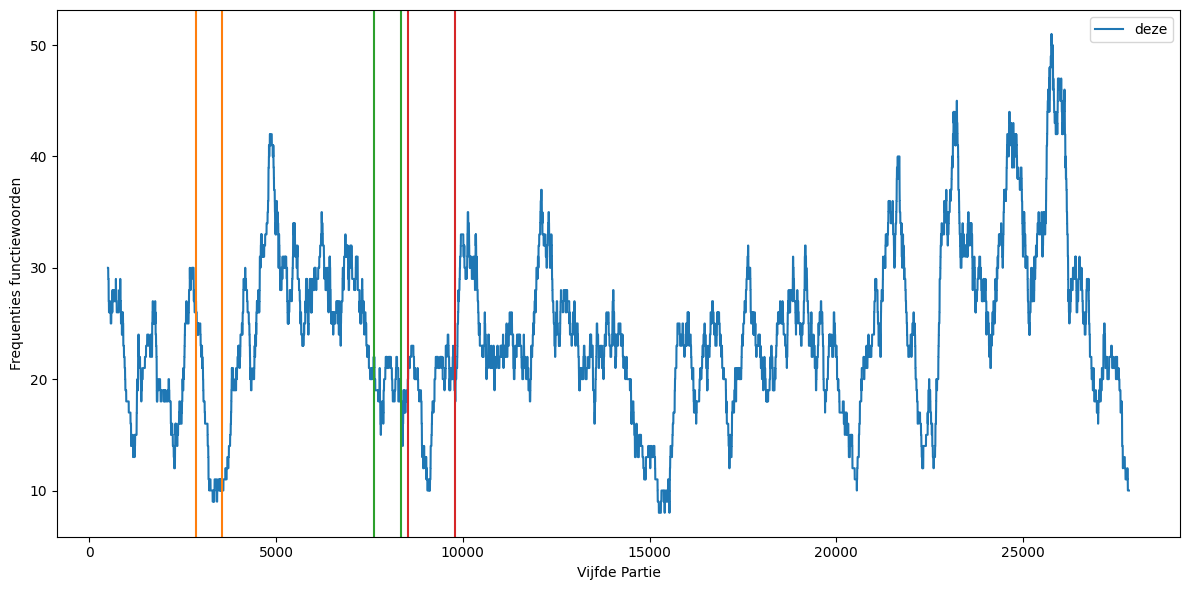

In [307]:
#Visualisation of function word frequencies in the entire Vijfde Partie.
VP_FULL = []

#Add each line to a list.
for entry, text in zip(corpus_df['title'], corpus_df['lines_lemmatized']):
    if entry == "vijfde partie":
        VP_FULL += text
    else:
        continue

important_matches = ['deze'] #Change this to whatever function word(s) you want to analyse

#dictionary with function word frequenices for each line
counts = {}
for word in important_matches:
    word_counts = []

    for verse in VP_FULL:
        count = verse.split().count(word)
        word_counts.append(count)
    counts[word] = word_counts
    
#Plot graph
df_counts_pos = pd.DataFrame(counts)

window_size = 500
rolling = df_counts_pos.rolling(window_size).sum()
plt.figure(figsize=(12, 6))
for word in important_matches:
    plt.plot(rolling.index, rolling[word], label=word)
    
plt.xlabel("Vijfde Partie")
plt.ylabel(f"Frequenties functiewoorden")
plt.legend()
plt.tight_layout()

#plot the start of part 1, part 2 and part 3 of the Woeringen-adaptation
for idx, v in enumerate(VP_FULL): #Velthem's text
    if '''koen hoofs mild en waard''' in v: # start of Velthem's first adaptation segment
        start_part1 = idx
    if '''NOU-P hij willen dies gehengen''' in v: # start of Velthem's second adaptation segment   
        start_part2 = idx
    if '''van de parlement dat om NOU-P zijn hoe het weder beginnen -''' in v: # start of Velthem's third adaptation segment   
        start_part3 = idx
        
plt.axvline(start_part1, color='C1', label="Start Velthem's adaptation segment 1")
plt.axvline(start_part2, color='C2', label="Start Velthem's adaptation segment 2")
plt.axvline(start_part3, color='C3', label="Start Velthem's adaptation segment 3")
plt.axvline(3562, color='C1', label="End Velthem's adaptation segment 1")
plt.axvline(8340, color='C2', label="End Velthem's adaptation segment 2")
plt.axvline(9803, color='C3', label="End Velthem's adaptation segment 3")


plt.show()

In [233]:
print('Positive loadings:')
print('\n'.join(f'{w} -> {s}' for s, w in vocab_weights[-20:]))

Positive loadings:
men -> 0.08299989435117179
moeten -> 0.08434845616872859
dies -> 0.08964214016376568
mogen -> 0.09018875683549761
zij -> 0.09426393412034438
door -> 0.0954455993469792
jegen -> 0.1066434974915726
nie -> 0.109810154448911
tussen -> 0.11060879894540267
toe -> 0.14891624574644433
ten -> 0.14973607657623902
toen -> 0.1533535405846199
ne -> 0.1558540899093327
bij -> 0.17793400453768193
van -> 0.18213167946863237
met -> 0.18951686267823065
nochtan -> 0.19291086559805484
beide -> 0.1962761631822646
die -> 0.19722054225155883
want -> 0.20169192185803447


In [234]:
#Making a dataframe with the frequencies of the top 10 positive function words for PC1
df_10pos = pd.DataFrame(vocab_weights[-10:], columns=['Pos Loadings (PC1)', 'Function Word'])
SbW = []
WA = []
VP = []

#Add the frequencies of each rhyme pair
for entry, text in zip(segment_df_all['title'], segment_df_all['all_text']):
    if entry == "rijmkroniek van woeringen":
        SbW += text.split() 
    elif entry == "woeringen-adaptatie":
        WA += text.split()
    elif entry == "vijfde partie (zonder woeringen-adaptatie)":
        VP += text.split()
    else:
        print('ERROR')
#print(VP[:10], WA[:10], SbW[:10]) #test
#print(len(df_10neg))

SbW_result = []
WA_result = []
VP_result = []
SbW_result_rel = []
WA_result_rel = []
VP_result_rel = []
for FunctionWord in df_10pos['Function Word']:
    SbW_cnt = 0
    WA_cnt = 0
    VP_cnt = 0
    for entry in SbW:
        if entry == FunctionWord:
            SbW_cnt += 1
        else:
            continue
    SbW_result.append(SbW_cnt) #absolute frequency
    SbW_result_rel.append(SbW_cnt / len(SbW)) #Relative frequency (divided by all words, not only function words)
    for entry in WA:
        if entry == FunctionWord:
            WA_cnt += 1
        else:
            continue
    WA_result.append(WA_cnt)
    WA_result_rel.append(WA_cnt / len(WA)) #Relative frequency 
    for entry in VP:
        if entry == FunctionWord:
            VP_cnt += 1
        else:
            continue
    VP_result.append(VP_cnt)
    VP_result_rel.append(VP_cnt / len(VP)) #Relative frequency

df_10pos['Vijfde Partie z/ adapt (Abs.)'], df_10pos['Woeringen-adaptatie (Abs.)'], df_10pos['Slag bij Woeringen (Abs.)'] = VP_result, WA_result, SbW_result
df_10pos['Vijfde Partie z/ adapt (Rel.)'], df_10pos['Woeringen-adaptatie (Rel.)'], df_10pos['Slag bij Woeringen (Rel.)'] = VP_result_rel, WA_result_rel, SbW_result_rel
df_10pos = df_10pos.iloc[::-1]

pd.set_option('display.max_rows', None)

#highlight rows where a function word never appears in the Slag bij Woeringen (=blue), but it does appear in the adaptation
def highlight(df):
    return np.tile(np.where((df['Slag bij Woeringen (Abs.)'] == 0) & (df['Woeringen-adaptatie (Abs.)'] != 0) , 'background-color: lightblue', '')[:,None],
                   (1, df.shape[1]))

df_10pos = df_10pos.style.apply(highlight, axis=None)
df_10pos.to_excel("figures/Function_words_positive_loadings.xlsx", engine="openpyxl", index=False)
df_10pos

,Pos Loadings (PC1),Function Word,Vijfde Partie z/ adapt (Abs.),Woeringen-adaptatie (Abs.),Slag bij Woeringen (Abs.),Vijfde Partie z/ adapt (Rel.),Woeringen-adaptatie (Rel.),Slag bij Woeringen (Rel.)
9,0.201692,want,529,93,530,0.003647,0.005641,0.011482
8,0.197221,die,5529,723,2350,0.038113,0.043858,0.050912
7,0.196276,beide,86,27,127,0.000593,0.001638,0.002751
6,0.192911,nochtan,100,36,125,0.000689,0.002184,0.002708
5,0.189517,met,1540,223,818,0.010616,0.013527,0.017722
4,0.182132,van,2845,528,1593,0.019611,0.032029,0.034512
3,0.177934,bij,279,46,267,0.001923,0.002790,0.005784
2,0.155854,ne,883,116,492,0.006087,0.007037,0.010659
1,0.153354,toen,728,193,408,0.005018,0.011708,0.008839
0,0.149736,ten,177,28,144,0.001220,0.001699,0.003120


In [235]:
results = []
Imp_Func = ['ten']
for entry in vocab_weights[-10:]:
    if entry[1] in Imp_Func:
        results.append(entry)
results

[(0.14973607657623902, 'ten')]

In [236]:
#Loadings for the function words that are most distinctive of the Woeringen adaptation
weights = []
Imp_Func = ['mogen', 'door', 'voor', 'tot', 'daar', 'tussen', 'men', 'zij']
for entry in vocab_weights:
    if entry[1] in Imp_Func:
        weights.append(entry)

df_8 = pd.DataFrame(weights, columns=['Pos Loadings (PC1)', 'Function Word'])
SbW = []
WA = []
VP = []

#Add the frequencies of each rhyme pair
for entry, text in zip(segment_df_all['title'], segment_df_all['all_text']):
    if entry == "rijmkroniek van woeringen":
        SbW += text.split() 
    elif entry == "woeringen-adaptatie":
        WA += text.split()
    elif entry == "vijfde partie (zonder woeringen-adaptatie)":
        VP += text.split()
    else:
        print('ERROR')
#print(VP[:10], WA[:10], SbW[:10]) #test
#print(len(df_8))

SbW_result = []
WA_result = []
VP_result = []
SbW_result_rel = []
WA_result_rel = []
VP_result_rel = []
for FunctionWord in df_8['Function Word']:
    SbW_cnt = 0
    WA_cnt = 0
    VP_cnt = 0
    for entry in SbW:
        if entry == FunctionWord:
            SbW_cnt += 1
        else:
            continue
    SbW_result.append(SbW_cnt) #absolute frequency
    SbW_result_rel.append(SbW_cnt / len(SbW)) #Relative frequency (divided by all words, not only function words)
    for entry in WA:
        if entry == FunctionWord:
            WA_cnt += 1
        else:
            continue
    WA_result.append(WA_cnt)
    WA_result_rel.append(WA_cnt / len(WA)) #Relative frequency 
    for entry in VP:
        if entry == FunctionWord:
            VP_cnt += 1
        else:
            continue
    VP_result.append(VP_cnt)
    VP_result_rel.append(VP_cnt / len(VP)) #Relative frequency

df_8['Vijfde Partie z/ adapt (Abs.)'], df_8['Woeringen-adaptatie (Abs.)'], df_8['Slag bij Woeringen (Abs.)'] = VP_result, WA_result, SbW_result
df_8['Vijfde Partie z/ adapt (Rel.)'], df_8['Woeringen-adaptatie (Rel.)'], df_8['Slag bij Woeringen (Rel.)'] = VP_result_rel, WA_result_rel, SbW_result_rel

pd.set_option('display.max_rows', None)

#highlight rows where a function word never appears in the Slag bij Woeringen (=blue), but it does appear in the adaptation
def highlight(df):
    return np.tile(np.where((df['Slag bij Woeringen (Abs.)'] == 0) & (df['Woeringen-adaptatie (Abs.)'] != 0) , 'background-color: lightblue', '')[:,None],
                   (1, df.shape[1]))

df_8 = df_8.style.apply(highlight, axis=None)
df_8.to_excel("figures/Adaptation_function_words_loadings.xlsx", engine="openpyxl", index=False)
df_8

,Pos Loadings (PC1),Function Word,Vijfde Partie z/ adapt (Abs.),Woeringen-adaptatie (Abs.),Slag bij Woeringen (Abs.),Vijfde Partie z/ adapt (Rel.),Woeringen-adaptatie (Rel.),Slag bij Woeringen (Rel.)
0,0.045625,daar,3373,468,1100,0.023251,0.028389,0.023831
1,0.048383,tot,311,48,110,0.002144,0.002912,0.002383
2,0.064220,voor,466,68,178,0.003212,0.004125,0.003856
3,0.083000,men,964,92,378,0.006645,0.005581,0.008189
4,0.090189,mogen,532,53,246,0.003667,0.003215,0.005330
5,0.094264,zij,2680,274,1103,0.018474,0.016621,0.023896
6,0.095446,door,106,18,62,0.000731,0.001092,0.001343
7,0.110609,tussen,73,18,55,0.000503,0.001092,0.001192


### Loadings PC2

Checking the top positive and negative loadings in relation to PC2:

In [453]:
vocab = vectorizer.get_feature_names_out()
vocab_weights_pc2 = sorted(zip(comps[:, 1], vocab)) # zip with second PC, at index 1

In [454]:
print('Negative loadings:')
print('\n'.join(f'{w} -> {s}' for s, w in vocab_weights_pc2[:20]))

Negative loadings:
wel -> -0.21422560502789262
hebben -> -0.20730774409773914
hij -> -0.19789876388438268
willen -> -0.19444291920579806
dus -> -0.182363906114831
op -> -0.17916426298287286
gij -> -0.16571317116688378
er -> -0.16443325661554212
binnen -> -0.16148085579219676
over -> -0.15556862587803094
hoe -> -0.14436986930965356
het -> -0.1390856102357962
te -> -0.12204231493287626
toen -> -0.11815691194272814
nu -> -0.11478632561558826
kunnen -> -0.11132536642234248
achter -> -0.11033463135747389
dit -> -0.09323995672132408
dies -> -0.09130874820251632
wil -> -0.08815559178487757


In [455]:
print('Positive loadings:')
print('\n'.join(f'{w} -> {s}' for s, w in vocab_weights_pc2[-20:]))

Positive loadings:
ook -> 0.07429847193009649
ter -> 0.07781931224821739
al -> 0.08925695177296311
bij -> 0.09264329660047876
maar -> 0.09407117863625379
nie -> 0.096776725312451
elk -> 0.0981136249551355
en -> 0.1034158431647534
haar -> 0.10444741662826351
worden -> 0.12032815256004244
daarna -> 0.13228252620978254
ons -> 0.14028739230883286
noch -> 0.14031377305596293
als -> 0.163156935443064
na -> 0.17924955832903888
alzo -> 0.18379327019235864
in -> 0.1887071932580704
mede -> 0.1921723503521403
zullen -> 0.21271498520475243
dan -> 0.2597444091640927
